In [7]:


import pandas as pd
df = pd.read_csv("../data/raw/dataset.csv") # Asegúrate de que la ruta coincida con donde guardaste el archivo
print(df.shape)
print(df.dtypes)
print(df.head())
print(df.tail())
assert not df.empty


(520, 17)
age                   int64
gender                  str
polyuria                str
polydipsia              str
sudden_weight_loss      str
weakness                str
polyphagia              str
genital_thrush          str
visual_blurring         str
itching                 str
irritability            str
delayed_healing         str
partial_paresis         str
muscle_stiffness        str
alopecia                str
obesity                 str
class                   str
dtype: object
   age gender polyuria polydipsia sudden_weight_loss weakness polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  genital_thrush visual_blurring itching ir

6. Construir la auditoría

In [10]:
audit = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "ausentes": df.isna().sum(),
    "porcentaje_ausente": (df.isna().mean()*100).round(2),
    "unicos": df.nunique(dropna=False)
}).sort_values("porcentaje_ausente", ascending=False)

print("Duplicados:", df.duplicated().sum())
display(audit)

Duplicados: 269


,tipo,ausentes,porcentaje_ausente,unicos
age,int64,0,0.0,51
gender,str,0,0.0,2
polyuria,str,0,0.0,2
polydipsia,str,0,0.0,2
sudden_weight_loss,str,0,0.0,2
weakness,str,0,0.0,2
polyphagia,str,0,0.0,2
genital_thrush,str,0,0.0,2
visual_blurring,str,0,0.0,2
itching,str,0,0.0,2


7. Definir target y retirar fugas

In [11]:
TARGET = "class"
DROP_COLUMNS = []  # deja [] si no aplica

assert TARGET in df.columns
X = df.drop(columns=[TARGET] + DROP_COLUMNS)
y = df[TARGET]

print(y.value_counts(dropna=False))
assert y.notna().all()
assert y.nunique() >= 2

class
Positive    320
Negative    200
Name: count, dtype: int64


Paso 8: Separar tipos y crear preprocesamiento

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])
print("Numéricas:", len(num_cols), "| Categóricas:", len(cat_cols))

Numéricas: 1 | Categóricas: 15


Paso 9: Dividir, baseline y SVM

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score

Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.20,random_state=42,stratify=y)
dummy=Pipeline([("prep",preprocess),("model",DummyClassifier(strategy="most_frequent"))])
svm=Pipeline([("prep",preprocess),("model",SVC(C=1,gamma="scale",random_state=42))])
for name,model in {"dummy":dummy,"svm":svm}.items():
    model.fit(Xtr,ytr)
    pred=model.predict(Xte)
    print(name, f1_score(yte,pred,average="macro"))
print(classification_report(yte,svm.predict(Xte)))

dummy 0.38095238095238093
svm 0.9796875
              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97        40
    Positive       0.98      0.98      0.98        64

    accuracy                           0.98       104
   macro avg       0.98      0.98      0.98       104
weighted avg       0.98      0.98      0.98       104



c:\Users\kebaez\Downloads\Ciencia de DatosII\Unidad I\Ejercicio 02\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


10. Crear pruebas del dataset

In [26]:
import pandas as pd

TARGET = "class"
REQUIRED = {TARGET, "Age"} 

def load_data():
    return pd.read_csv("data/raw/dataset.csv")

def test_dataset_is_not_empty():
    assert not load_data().empty

def test_required_columns_exist():
    assert REQUIRED <= set(load_data().columns)

def test_target_has_no_missing_and_two_classes():
    y = load_data()[TARGET]
    assert y.notna().all()
    assert y.nunique() >= 2

En la terminal Ejecute

env:PYTHONPATH="src"
py -m pytest -q

Paso 2: Crear el catálogo de modelos


In [29]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

models = {
    "logistic": Pipeline([("prep",preprocess),("model",LogisticRegression(max_iter=2000))]),
    "svm_c1": Pipeline([("prep",preprocess),("model",SVC(C=1,random_state=42))]),
    "svm_c10": Pipeline([("prep",preprocess),("model",SVC(C=10,random_state=42))]),
    "rf_100": Pipeline([("prep",preprocess),("model",RandomForestClassifier(n_estimators=100,max_depth=8,random_state=42,n_jobs=-1))]),
    "rf_300": Pipeline([("prep",preprocess),("model",RandomForestClassifier(n_estimators=300,max_depth=8,random_state=42,n_jobs=-1))]),
    "boost": Pipeline([("prep",preprocess),("model",HistGradientBoostingClassifier(max_depth=6,random_state=42))])
}

3. Medir tres veces

In [35]:
import warnings
warnings.filterwarnings("ignore")

from time import perf_counter
from pathlib import Path
import joblib, numpy as np, pandas as pd
from sklearn.metrics import f1_score, recall_score

# Usamos ../ para salir de la carpeta notebooks y guardar en la raíz
out_dir = Path("../reports/models")
out_dir.mkdir(parents=True, exist_ok=True)

rows = []
for name, model in models.items():
    fit_times = []
    for repetition in range(3):
        start = perf_counter()
        model.fit(Xtr, ytr)
        fit_times.append(perf_counter() - start)
    
    start = perf_counter()
    pred = model.predict(Xte)
    predict_ms = (perf_counter() - start) * 1000
    
    # Guardamos el modelo en la nueva ruta
    path = out_dir / f"{name}.joblib"
    joblib.dump(model, path)
    
    rows.append({
        "model": name,
        "f1_macro": f1_score(yte, pred, average="macro"),
        "recall_macro": recall_score(yte, pred, average="macro"),
        "fit_median_s": np.median(fit_times),
        "predict_ms": predict_ms,
        "size_kb": path.stat().st_size / 1024
    })

results = pd.DataFrame(rows)
display(results.sort_values("f1_macro", ascending=False))

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb
3,rf_100,0.989795,0.987500,0.156150,42.8442,616.354492
5,boost,0.979868,0.984375,0.177883,11.4391,187.501953
4,rf_300,0.979688,0.979688,0.437986,142.6862,1833.073242
1,svm_c1,0.979688,0.979688,0.031402,9.6275,41.708984
2,svm_c10,0.969670,0.971875,0.025225,6.8944,30.990234
0,logistic,0.940092,0.948438,0.026444,8.8836,7.650391


4. Comparar PCA con y sin PCA

In [37]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Como tu dataset tiene variables numéricas y categóricas, aplicamos PCA solo al bloque numérico.
# Usamos los num_cols definidos en tu preprocesamiento (Paso 8 del LAB02)

X_train_num = Xtr[num_cols].copy()
X_test_num = Xte[num_cols].copy()

# Rellenar valores nulos (si los hay) para poder aplicar StandardScaler y PCA
X_train_num = X_train_num.fillna(X_train_num.median())

svm_pca = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=.95, random_state=42)),
    ("model", SVC(C=1, probability=True, random_state=42))
])

svm_pca.fit(X_train_num, ytr)
print("Componentes originales:", len(num_cols))
print("Componentes tras PCA (95% varianza):", svm_pca.named_steps["pca"].n_components_)

Componentes originales: 1
Componentes tras PCA (95% varianza): 1


Paso 5: Crear dos mapas t-SNE

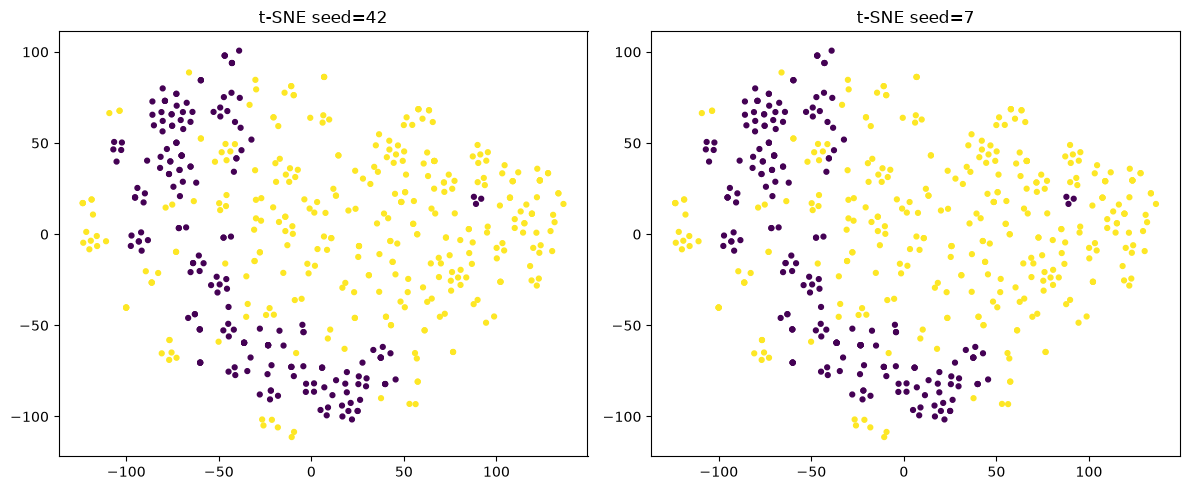

Gráfica guardada en: C:\Users\kebaez\Downloads\Ciencia de DatosII\Unidad I\Ejercicio 02\notebooks\reports\tsne_two_seeds.png


In [45]:
from pathlib import Path
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

sample = X.sample(n=min(1000, len(X)), random_state=42)
y_sample = y.loc[sample.index]
encoded = preprocess.fit_transform(sample)
if hasattr(encoded, "toarray"):
    encoded = encoded.toarray()
encoded = np.asarray(encoded)

if encoded.shape[1] < 2:
    raise ValueError("t-SNE requiere al menos dos variables de entrada.")

perplexity = min(30, len(sample) - 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, seed in zip(axes, [42, 7]):
    embedding = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        init="pca",
        learning_rate="auto",
    ).fit_transform(encoded)
    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=pd.Categorical(y_sample).codes,
        s=12,
        cmap="viridis",
    )
    ax.set_title(f"t-SNE seed={seed}")

project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent
output_dir = project_dir / "reports"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "tsne_two_seeds.png"
fig.tight_layout()
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Gráfica guardada en: {output_path.resolve()}")